# Predicting University Performance Scores Using Academic and Research Indicators

## Overview

This project develops a regression model to predict university ranking scores using academic, research, and innovation indicators.

The objective is to understand which factors contribute to university performance and compare different regression algorithms to identify the best-performing model.

## Dataset Description

The dataset contains university performance indicators collected across different countries and years.

The target variable is:

**score** - the overall university performance score.

# Import Required Libraries

In [1]:
# NumPy provides support for numerical operations and array handling
import numpy as np

# Pandas is used for loading, cleaning, and manipulating datasets
import pandas as pd

# Matplotlib is used for creating basic visualizations
import matplotlib.pyplot as plt

# Seaborn provides advanced statistical visualizations
import seaborn as sns

# Splits the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Standardizes numerical features so variables have similar scales
from sklearn.preprocessing import StandardScaler

# Traditional Linear Regression model
from sklearn.linear_model import LinearRegression

# Linear regression optimized using gradient descent
from sklearn.linear_model import SGDRegressor

# Decision Tree regression model
from sklearn.tree import DecisionTreeRegressor

# Ensemble regression model using multiple decision trees
from sklearn.ensemble import RandomForestRegressor


# Mean squared error measures the average squared difference between
# actual and predicted values
from sklearn.metrics import mean_squared_error

# Mean absolute error measures the average absolute difference between
# actual and predicted values
from sklearn.metrics import mean_absolute_error

# R² score measures how well the model explains variation in the target variable
from sklearn.metrics import r2_score

# Joblib is used to save and load trained machine learning models
import joblib

# OS module provides functions for interacting with the operating system, such as file and directory management
import os

## Loading the Dataset

The dataset is loaded into a Pandas DataFrame to begin the data exploration and preprocessing process.

After loading, the first rows of the dataset are displayed to verify that the data has been imported correctly and to understand the structure of the available features.

In [2]:
# Load the dataset

df = pd.read_csv("data/cwurData.csv")

# Display the first few rows
df.head(100)

,world_rank,institution,country,national_rank,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,1,Harvard University,USA,1,7,9,1,1,1,1,NaN,5,100.00,2012
1,2,Massachusetts Institute of Technology,USA,2,9,17,3,12,4,4,NaN,1,91.67,2012
2,3,Stanford University,USA,3,17,11,5,4,2,2,NaN,15,89.50,2012
3,4,University of Cambridge,United Kingdom,1,10,24,4,16,16,11,NaN,50,86.17,2012
4,5,California Institute of Technology,USA,4,2,29,7,37,22,22,NaN,18,85.21,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,University of Texas MD Anderson Cancer Center,USA,58,101,101,101,95,46,66,NaN,100,43.88,2012
96,97,University of Nottingham,United Kingdom,6,101,101,87,101,101,101,NaN,92,43.79,2012
97,98,University of Bristol,United Kingdom,7,101,101,78,75,81,86,NaN,101,43.77,2012
98,99,Utrecht University,Netherlands,2,100,101,101,65,101,60,NaN,101,43.47,2012


## Dataset Overview

Before cleaning the dataset, we inspect its structure to understand the number of records, available features, and data types.

This helps identify potential issues such as missing values, incorrect data formats, or columns that may require preprocessing before model training.

In [3]:
# Display dataset information including data types and missing values
df.info()

# Check the number of rows and columns in the dataset
df.shape

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   world_rank            2200 non-null   int64  
 1   institution           2200 non-null   str    
 2   country               2200 non-null   str    
 3   national_rank         2200 non-null   int64  
 4   quality_of_education  2200 non-null   int64  
 5   alumni_employment     2200 non-null   int64  
 6   quality_of_faculty    2200 non-null   int64  
 7   publications          2200 non-null   int64  
 8   influence             2200 non-null   int64  
 9   citations             2200 non-null   int64  
 10  broad_impact          2000 non-null   float64
 11  patents               2200 non-null   int64  
 12  score                 2200 non-null   float64
 13  year                  2200 non-null   int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 240.8 KB


(2200, 14)

In [4]:
# Check the number of missing values in each column
df.isnull().sum()

world_rank                0
institution               0
country                   0
national_rank             0
quality_of_education      0
alumni_employment         0
quality_of_faculty        0
publications              0
influence                 0
citations                 0
broad_impact            200
patents                   0
score                     0
year                      0
dtype: int64

## Handling Missing Values

The dataset contains missing values only in the `broad_impact` column.

Since `broad_impact` is a numerical ranking feature, the missing values will be replaced using the median value of the existing data. The median is preferred because it is less affected by extreme values and maintains the distribution of the ranking data.

After filling the missing values, we verify that no missing values remain in the dataset.

In [5]:
# Calculate the median value of the broad_impact column
median_value = df["broad_impact"].median()

# Replace missing values in broad_impact with the median value
df["broad_impact"] = df["broad_impact"].fillna(median_value)

# Confirm that all missing values have been handled
df.isnull().sum()

world_rank              0
institution             0
country                 0
national_rank           0
quality_of_education    0
alumni_employment       0
quality_of_faculty      0
publications            0
influence               0
citations               0
broad_impact            0
patents                 0
score                   0
year                    0
dtype: int64

## Checking Duplicate Records

Duplicate records can negatively affect machine learning models by causing certain observations to appear more frequently than they should.

We check for duplicate rows to ensure that each university record appears only once in the dataset.

In [6]:
# Check the number of duplicate rows in the dataset

df.duplicated().sum()

np.int64(0)

## Checking Data Types

Machine learning algorithms require data to be in the correct format.

This step checks the data types of each column to identify:
- Numerical features that can be used directly in model training.
- Categorical features that may need encoding.
- Any columns that require type conversion before preprocessing.

In [7]:
# Display information about the dataset including:
# - Column names
# - Number of non-null values
# - Data types

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   world_rank            2200 non-null   int64  
 1   institution           2200 non-null   str    
 2   country               2200 non-null   str    
 3   national_rank         2200 non-null   int64  
 4   quality_of_education  2200 non-null   int64  
 5   alumni_employment     2200 non-null   int64  
 6   quality_of_faculty    2200 non-null   int64  
 7   publications          2200 non-null   int64  
 8   influence             2200 non-null   int64  
 9   citations             2200 non-null   int64  
 10  broad_impact          2200 non-null   float64
 11  patents               2200 non-null   int64  
 12  score                 2200 non-null   float64
 13  year                  2200 non-null   int64  
dtypes: float64(2), int64(10), str(2)
memory usage: 240.8 KB


## Creating the Modeling Dataset

A separate dataset is created for machine learning to avoid modifying the original dataset.

The categorical variables (**institution** and **country**) are removed because they contain text values and many unique categories, which are not directly useful for this regression task.

The ranking columns (**world_rank** and **national_rank**) are also removed because they represent final ranking information and could introduce data leakage.

The remaining features represent academic, research, and innovation indicators that can be used to predict the university score.

In [8]:
# Create a copy of the dataset for machine learning

model_df = df.copy()

# Drop categorical columns and ranking columns
model_df = model_df.drop(
    columns=[
        "institution",
        "country",
        "world_rank",
        "national_rank"
    ]
)

# Display the first rows of the modeling dataset

model_df.head(100)

,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,score,year
0,7,9,1,1,1,1,496.0,5,100.00,2012
1,9,17,3,12,4,4,496.0,1,91.67,2012
2,17,11,5,4,2,2,496.0,15,89.50,2012
3,10,24,4,16,16,11,496.0,50,86.17,2012
4,2,29,7,37,22,22,496.0,18,85.21,2012
...,...,...,...,...,...,...,...,...,...,...
95,101,101,101,95,46,66,496.0,100,43.88,2012
96,101,101,87,101,101,101,496.0,92,43.79,2012
97,101,101,78,75,81,86,496.0,101,43.77,2012
98,100,101,101,65,101,60,496.0,101,43.47,2012


# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the characteristics of the dataset before building machine learning models.

The analysis helps identify:
- The distribution of the target variable (**score**).
- Relationships between academic and research indicators.
- Features that may have the greatest influence on university performance.

For this project, the following visualizations are used:

1. Distribution of University Scores (Histogram)
2. Correlation Heatmap
3. Scatter Plots of Selected Features against the Target Variable

The insights obtained from these visualizations will guide feature selection and support the interpretation of the regression models.

## Correlation Heatmap

The correlation heatmap shows the strength and direction of the relationships between numerical variables in the modeling dataset.

This visualization helps identify features that are strongly associated with the target variable (`score`) and supports feature selection before model training.

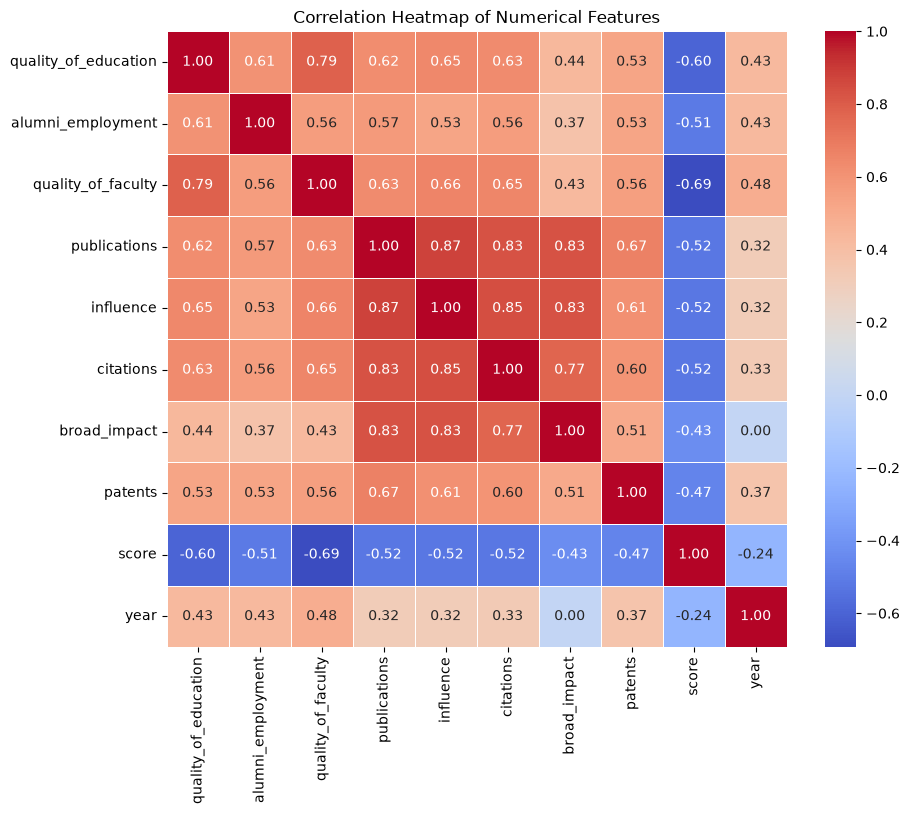

In [9]:
# Compute the correlation matrix
correlation_matrix = model_df.corr()

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numerical Features")

plt.show()

## Interpretation

The correlation heatmap reveals the relationships between the selected features and the target variable (`score`).

Key observations include:

- **quality_of_faculty** has the strongest relationship with **score** (−0.69), suggesting that faculty quality is an important factor associated with university performance.
- **quality_of_education** also shows a strong relationship with **score** (−0.60).
- **publications**, **influence**, and **citations** exhibit moderate negative correlations with **score**, indicating that research performance contributes to the overall university score.
- **year** has a weak relationship with **score** (−0.24), suggesting that the year of ranking has little influence on the prediction.

The negative correlations occur because lower numerical rankings represent better university performance, while higher **score** values indicate stronger institutions. Therefore, better rankings are naturally associated with higher scores.

Overall, the selected features demonstrate meaningful relationships with the target variable and are suitable for regression modeling.

## Distribution of University Scores

The histogram below illustrates the distribution of the target variable (**score**) across all universities in the dataset.

Examining the distribution of the target variable helps identify how university scores are spread, detect potential skewness or outliers, and assess whether the data is suitable for regression modeling.

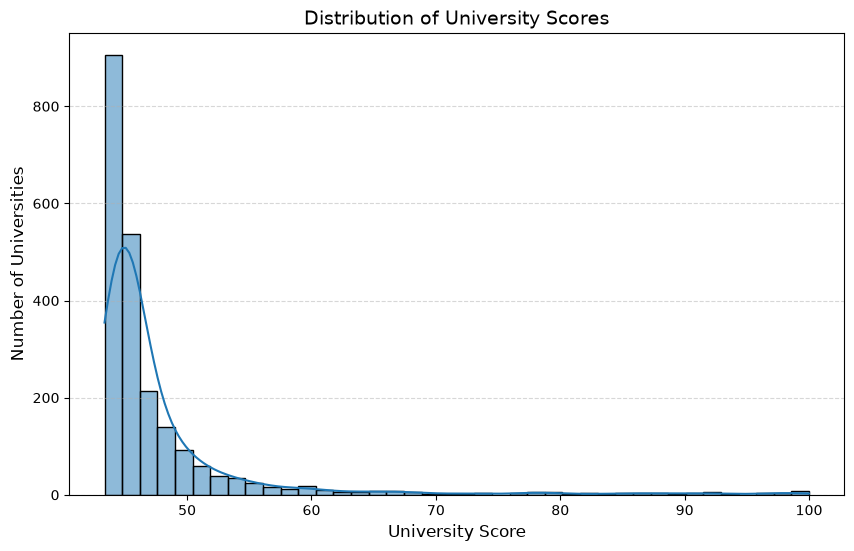

In [10]:
# Plot the distribution of university scores

plt.figure(figsize=(10, 6))

sns.histplot(
    data=model_df,
    x="score",
    bins=40,
    kde=True,
    edgecolor="black"
)

plt.title("Distribution of University Scores", fontsize=14)
plt.xlabel("University Score", fontsize=12)
plt.ylabel("Number of Universities", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## Interpretation

The histogram shows that university scores are not evenly distributed across the dataset. Most universities have scores concentrated between **43 and 50**, while only a small number of universities achieve scores above **70**.

The distribution is **positively (right) skewed**, indicating that high-performing universities are less common than universities with average performance. This suggests that the dataset contains many average-performing institutions and relatively few top-performing universities.

Understanding this distribution is important because it provides insight into the target variable before training the regression models and helps in interpreting the model's predictions.

## Scatter Plots of Selected Features

Scatter plots are used to visualize the relationship between the target variable (**score**) and selected academic indicators.

The selected features were chosen based on the correlation analysis because they exhibited relatively stronger relationships with the target variable.

The plots help determine whether a linear relationship exists between each feature and the university score before training the regression models.

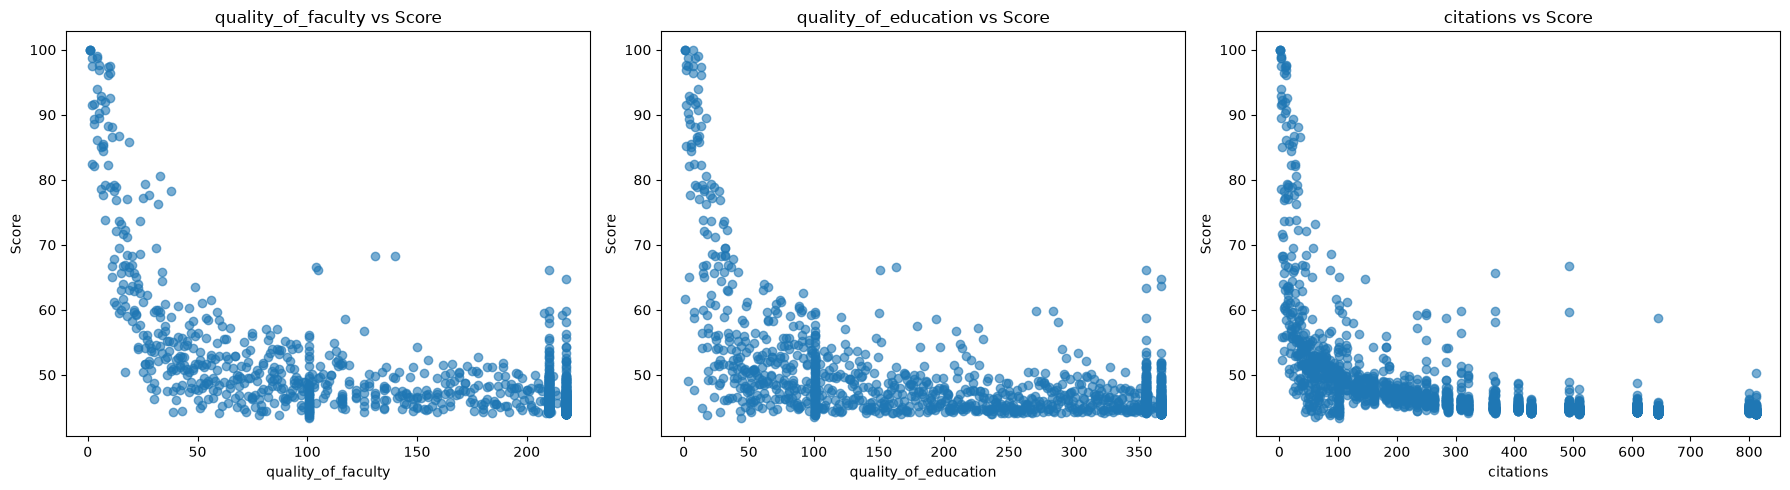

In [11]:
# Create scatter plots for selected features

features = [
    "quality_of_faculty",
    "quality_of_education",
    "citations"
]

plt.figure(figsize=(18, 5))

for i, feature in enumerate(features, 1):
    plt.subplot(1, 3, i)
    plt.scatter(model_df[feature], model_df["score"], alpha=0.6)
    plt.title(f"{feature} vs Score")
    plt.xlabel(feature)
    plt.ylabel("Score")

plt.tight_layout()
plt.show()

## Interpretation

The scatter plots illustrate the relationship between selected academic indicators and the university score.

The following observations can be made:

- **Quality of Faculty vs Score:** Universities with better faculty rankings (lower numerical values) generally achieve higher scores. As the faculty ranking value increases, the university score tends to decrease.

- **Quality of Education vs Score:** A similar inverse relationship is observed. Universities with better education rankings tend to have higher overall scores, while poorer rankings are associated with lower scores.

- **Citations vs Score:** Universities with stronger citation performance also tend to achieve higher scores. Although the relationship is not perfectly linear, there is a noticeable downward trend as citation ranking values increase.

Overall, the scatter plots confirm the patterns observed in the correlation heatmap. The selected features show meaningful relationships with the target variable and are appropriate predictors for building the regression models.

## Define the Feature Matrix and Target Variable

The dataset is divided into two parts:

- **Feature Matrix (`X`)**: Contains the predictor variables used to estimate the university score.
- **Target Variable (`y`)**: Contains the university `score`, which is the value the regression models will learn to predict.

In [12]:
# Define the feature matrix (X) and target variable (y)

X = model_df.drop(columns=["score"])
y = model_df["score"]

# Display the dimensions
print("Feature Matrix Shape:", X.shape)
print("Target Vector Shape :", y.shape)

Feature Matrix Shape: (2200, 9)
Target Vector Shape : (2200,)


In [13]:
# Display the feature names
print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['quality_of_education', 'alumni_employment', 'quality_of_faculty',
       'publications', 'influence', 'citations', 'broad_impact', 'patents',
       'year'],
      dtype='str')

Target:
score


## Split the Dataset into Training and Testing Sets

The dataset is divided into two subsets:

- **Training Set (80%)**: Used to train the regression models.
- **Testing Set (20%)**: Used to evaluate how well the trained models perform on unseen data.

An 80:20 split provides sufficient data for training while reserving a portion of the dataset for unbiased performance evaluation. The **random_state** is set to **42** to ensure that the split is reproducible.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Features:", X_train.shape)
print("Testing Features :", X_test.shape)

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features: (1760, 9)
Testing Features : (440, 9)
Training Labels : (1760,)
Testing Labels  : (440,)


# Feature Scaling

The predictor variables have different numerical scales. For example, variables such as **year** have values around **2012–2015**, while ranking indicators such as **quality_of_education**, **citations**, and **patents** have values ranging from **1 to 1000**.

To ensure that all features contribute equally during model training, the predictor variables are standardized using the **StandardScaler**.

Feature scaling is particularly important for **SGDRegressor (Gradient Descent Linear Regression)** because it improves convergence during optimization. The scaler is fitted only on the training data and then applied to both the training and testing datasets to prevent data leakage.

In [15]:
# Create a StandardScaler object
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the testing data
X_test_scaled = scaler.transform(X_test)

In [16]:
# Display the first five standardized training samples

pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
).head(100)

# Displaying the shapes of the standardized datasets
# print("Standardized Training Features:", X_train_scaled.shape)
# print("Standardized Testing Features :", X_test_scaled.shape)

,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,year
0,0.757493,0.324438,0.612093,0.047009,-0.134151,0.369311,-0.422352,-0.307706,0.888577
1,0.659299,0.656512,0.487424,-0.134067,0.655920,0.738947,0.394597,-0.962981,-0.420122
2,0.659299,0.104841,0.487424,0.646205,-0.005765,0.738947,0.606128,1.101135,-0.420122
3,0.659299,0.431559,0.487424,1.044571,0.787599,0.738947,1.284488,0.427658,-0.420122
4,0.659299,0.656512,0.487424,1.410015,1.692890,1.459362,1.780492,-0.223977,-0.420122
...,...,...,...,...,...,...,...,...,...
95,0.757493,-1.309150,0.612093,1.762289,1.208971,1.504623,1.682021,1.472457,0.888577
96,0.757493,-0.045128,0.113416,-0.506095,0.293804,-0.347332,-0.652119,-0.566176,0.888577
97,0.659299,0.656512,0.487424,0.514513,-0.094648,-0.188916,-0.002936,0.169188,-0.420122
98,-1.648258,0.656512,0.487424,-0.621325,-0.604902,-1.067746,-1.009534,0.427658,-0.420122


# Linear Regression Model

The first model trained is a **Linear Regression** model using Scikit-learn.

Linear Regression learns the relationship between the selected university ranking indicators and the overall university score by fitting a linear equation to the training data.

The trained model will be evaluated using the following regression metrics:

- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Coefficient of Determination (R²)

These metrics will help assess how accurately the model predicts university scores.

In [17]:
# Create the model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](9,)","[-0.63,-1.35,-4.77,...,-1.67,-0.58, 0.84]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,47.83
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,9
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(9)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](9,)","[99.89,47.11,30.93,...,17.34,14.36,12.72]"


## Make Predictions

After training, the Linear Regression model is used to predict university scores for the testing dataset. These predictions are compared with the actual scores to evaluate the model's performance.

In [18]:
# Predict the university scores

y_pred_linear = linear_model.predict(X_test_scaled)

In [19]:
# Calculate evaluation metrics

mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)

# Display the results

print("Linear Regression Performance")
print("-" * 30)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Linear Regression Performance
------------------------------
MSE  : 26.7540
RMSE : 5.1724
MAE  : 2.7345
R²   : 0.5033


# Linear Regression using Gradient Descent

The second model is a **Linear Regression model trained using Gradient Descent** through Scikit-learn's `SGDRegressor`.

Unlike the standard Linear Regression model, which computes the optimal solution directly, Gradient Descent learns the model parameters iteratively by minimizing the prediction error over multiple iterations.

This approach is particularly effective when the features have been standardized and allows the optimization process to be monitored using a loss curve.

In [20]:
# Creating the Models
gradient_model = SGDRegressor(
    loss="squared_error",
    learning_rate="constant",
    eta0=0.00001,
    max_iter=2000,
    tol=1e-4,
    random_state=42
)

gradient_model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method.Values must be in the range `[1, inf)`... versionadded:: 0.19",2000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, training will stopwhen (loss > best_loss - tol) for ``n_iter_no_change`` consecutiveepochs.Convergence is checked against the training loss or thevalidation loss depending on the `early_stopping` parameter.Values must be in the range `[0.0, inf)`... versionadded:: 0.19",0.0001
,"random_state random_state: int, RandomState instance, default=NoneUsed for shuffling the data, when ``shuffle`` is set to ``True``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"learning_rate learning_rate: str, default='invscaling'The learning rate schedule:- 'constant': `eta = eta0`- 'optimal': `eta = 1.0 / (alpha * (t + t0))` where t0 is chosen by a heuristic proposed by Leon Bottou.- 'invscaling': `eta = eta0 / pow(t, power_t)`- 'adaptive': eta = eta0, as long as the training keeps decreasing. Each time n_iter_no_change consecutive epochs fail to decrease the training loss by tol or fail to increase validation score by tol if early_stopping is True, the current learning rate is divided by 5.- 'pa1': passive-aggressive algorithm 1, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = min(eta0, loss/||x||**2)`.- 'pa2': passive-aggressive algorithm 2, see [1]_. Only with `loss='epsilon_insensitive'`. Update is `w += eta y x` with `eta = hinge_loss / (||x||**2 + 1/(2 eta0))`... versionadded:: 0.20 Added 'adaptive' option... versionadded:: 1.8 Added options 'pa1' and 'pa2'",'constant'
,"eta0 eta0: float, default=0.01The initial learning rate for the 'constant', 'invscaling' or'adaptive' schedules. The default value is 0.01.Values must be in the range `(0.0, inf)`.For PA-1 (`learning_rate=pa1`) and PA-II (`pa2`), it specifies theaggressiveness parameter for the passive-aggressive algorithm, see [1] where itis called C:- For PA-I it is the maximum step size.- For PA-II it regularizes the step size (the smaller `eta0` the more it regularizes).As a general rule-of-thumb for PA, `eta0` should be small when the data isnoisy.",1e-05
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide <sgd_mathematical_formulation>`.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds to L2 penalty, l1_ratio=1 to L1.Only used if `penalty` is 'elasticnet'.Values 

In [21]:
# Predict the university scores

y_pred_gradient = gradient_model.predict(X_test_scaled)

In [22]:
# Calculate the evaluation metrics

mse = mean_squared_error(y_test, y_pred_gradient)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_gradient)
r2 = r2_score(y_test, y_pred_gradient)

# Display the results

print("Gradient Descent Linear Regression")
print("-" * 35)
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

Gradient Descent Linear Regression
-----------------------------------
MSE  : 26.6994
RMSE : 5.1671
MAE  : 2.6948
R²   : 0.5043


# Decision Tree Regression

A **Decision Tree Regression** model was trained to predict university scores based on the selected university ranking indicators.

Unlike Linear Regression, which assumes a linear relationship between the predictor variables and the target variable, a Decision Tree recursively splits the dataset into smaller subsets based on feature values. This enables the model to learn more complex and non-linear relationships within the data.

The model is evaluated using the same regression metrics—Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the coefficient of determination (R²)—to allow a fair comparison with the Linear Regression models.

In [23]:
# Create the Model
decision_tree = DecisionTreeRegressor(
    random_state=42,
    max_depth=5
)

In [24]:
# Train the model
decision_tree.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max

In [25]:
# Predict on the test data
y_pred_tree = decision_tree.predict(X_test)

In [26]:
# Evaluate the Decision Tree Model

tree_mse = mean_squared_error(y_test, y_pred_tree)
tree_rmse = np.sqrt(tree_mse)
tree_mae = mean_absolute_error(y_test, y_pred_tree)
tree_r2 = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression")
print("-" * 25)

print(f"MSE  : {tree_mse:.4f}")
print(f"RMSE : {tree_rmse:.4f}")
print(f"MAE  : {tree_mae:.4f}")
print(f"R²   : {tree_r2:.4f}")

Decision Tree Regression
-------------------------
MSE  : 3.6300
RMSE : 1.9052
MAE  : 0.9809
R²   : 0.9326


### Interpretation

The Decision Tree Regression model achieved the best performance so far, with an R² score of **0.9326**. This indicates that the model explains approximately **93.26%** of the variation in university scores.

Compared to the Linear Regression and Gradient Descent models, the Decision Tree produced substantially lower prediction errors, as shown by the lower MSE, RMSE, and MAE values. This suggests that the relationship between the university ranking indicators and the overall university score is not purely linear, and the Decision Tree is better able to capture the complex patterns present in the dataset.

# Random Forest Regression

The final model trained is a **Random Forest Regressor**.

Random Forest is an ensemble learning algorithm that combines the predictions of multiple Decision Trees. Each tree is trained on a random subset of the training data and a random subset of the predictor variables. The final prediction is obtained by averaging the predictions from all the trees.

By combining multiple Decision Trees, Random Forest generally reduces overfitting, improves prediction accuracy, and provides better generalization to unseen data than a single Decision Tree.

The model is evaluated using the same regression metrics—Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and the coefficient of determination (R²)—to enable a fair comparison with the previous models.

In [27]:
# Create the model
random_forest = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of t

In [28]:
# Predict on the test data
y_pred_forest = random_forest.predict(X_test)

In [29]:
# Evaluate the Random Forest Model

forest_mse = mean_squared_error(y_test, y_pred_forest)
forest_rmse = np.sqrt(forest_mse)
forest_mae = mean_absolute_error(y_test, y_pred_forest)
forest_r2 = r2_score(y_test, y_pred_forest)

print("Random Forest Regression")
print("-" * 25)
print(f"MSE  : {forest_mse:.4f}")
print(f"RMSE : {forest_rmse:.4f}")
print(f"MAE  : {forest_mae:.4f}")
print(f"R²   : {forest_r2:.4f}")


Random Forest Regression
-------------------------
MSE  : 1.2556
RMSE : 1.1205
MAE  : 0.5333
R²   : 0.9767


## Model Comparison

The four regression models were evaluated using the same testing dataset and performance metrics.

Among all the models, the **Random Forest Regressor** achieved the best overall performance, producing the lowest prediction errors and the highest coefficient of determination (R² = 0.9767). This indicates that the model explains approximately **97.67%** of the variation in university scores.

The Decision Tree Regressor also performed well, but the Random Forest achieved higher accuracy by combining the predictions of multiple Decision Trees, reducing overfitting and improving generalization.

The Linear Regression and Gradient Descent models produced similar results because both learn the same linear relationship. However, their performance was lower since the relationship between the university ranking indicators and the university score appears to be more complex than a simple linear model can capture.

Based on these results, the **Random Forest Regressor** was selected as the best-performing model for deployment.

In [30]:
# Compare the performance of all trained models

results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Gradient Descent (SGD)",
        "Decision Tree",
        "Random Forest"
    ],
    "MSE": [
        mean_squared_error(y_test, y_pred_linear),
        mean_squared_error(y_test, y_pred_gradient),
        tree_mse,
        forest_mse
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_linear)),
        np.sqrt(mean_squared_error(y_test, y_pred_gradient)),
        tree_rmse,
        forest_rmse
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_linear),
        mean_absolute_error(y_test, y_pred_gradient),
        tree_mae,
        forest_mae
    ],
    "R²": [
        r2_score(y_test, y_pred_linear),
        r2_score(y_test, y_pred_gradient),
        tree_r2,
        forest_r2
    ]
})

# Display the best model first
results = results.sort_values(by="R²", ascending=False).reset_index(drop=True)

# Round values for better presentation
results.iloc[:, 1:] = results.iloc[:, 1:].round(4)

results

,Model,MSE,RMSE,MAE,R²
0,Random Forest,1.2556,1.1205,0.5333,0.9767
1,Decision Tree,3.6300,1.9052,0.9809,0.9326
2,Gradient Descent (SGD),26.6994,5.1671,2.6948,0.5043
3,Linear Regression,26.7540,5.1724,2.7345,0.5033


In [31]:
# Identify the best-performing model

best_row = results.iloc[0]
best_model_name = best_row["Model"]

print(f"Best Performing Model: {best_model_name}")
print(f"MSE  : {best_row['MSE']:.4f}")
print(f"RMSE : {best_row['RMSE']:.4f}")
print(f"MAE  : {best_row['MAE']:.4f}")
print(f"R²   : {best_row['R²']:.4f}")

Best Performing Model: Random Forest
MSE  : 1.2556
RMSE : 1.1205
MAE  : 0.5333
R²   : 0.9767


# Loss Curve for Gradient Descent

Unlike the standard Linear Regression model, Gradient Descent is an iterative optimization algorithm that updates the model parameters over multiple training iterations (epochs).

To visualize the learning process, the training loss and testing loss are recorded after each epoch. A decreasing loss indicates that the model is learning and improving its predictions over time.

The loss curves also help determine whether the model is converging and whether overfitting or underfitting is occurring during training.

In [32]:
# Track training and testing loss across epochs for the Gradient Descent model

n_epochs = 200
train_losses = []
test_losses = []

sgd_partial = SGDRegressor(
    loss="squared_error",
    learning_rate="adaptive",
    eta0=0.01,
    max_iter=1,
    tol=None,
    warm_start=True,
    random_state=42
)

for epoch in range(n_epochs):
    sgd_partial.partial_fit(X_train_scaled, y_train)

    train_pred = sgd_partial.predict(X_train_scaled)
    test_pred = sgd_partial.predict(X_test_scaled)

    train_losses.append(mean_squared_error(y_train, train_pred))
    test_losses.append(mean_squared_error(y_test, test_pred))
    
print(train_losses[:10])
print(test_losses[:10])

[28.287272463613228, 28.278758978096405, 28.278871354716735, 28.278915235512084, 28.27892273180023, 28.278923980346406, 28.278924196646866, 28.278924235684322, 28.278924242962244, 28.278924244351334]
[27.283173619242774, 27.273543364974763, 27.272848942246558, 27.272767895669883, 27.272757582158984, 27.272756218717777, 27.272756031926015, 27.272756005224128, 27.27275600121038, 27.272756000573025]


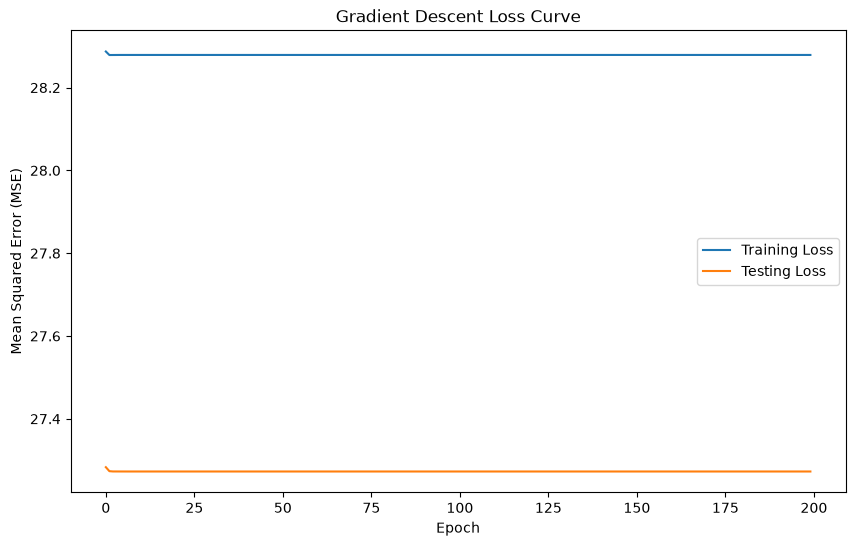

In [33]:
# Plot the training and testing loss curves

plt.figure(figsize=(10, 6))

plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Testing Loss")

plt.title("Gradient Descent Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error (MSE)")
plt.legend()

plt.show()

# Scatter Plot Before and After Training

A two-dimensional scatter plot is used to visualize the effect of model training.

Because the regression model uses multiple predictor variables, it is not possible to display all features in a single scatter plot. Therefore, **Quality of Faculty** is selected as a representative feature to illustrate the relationship with the target variable before training.

After training, the model's performance is visualized by comparing the actual university scores with the predicted scores.

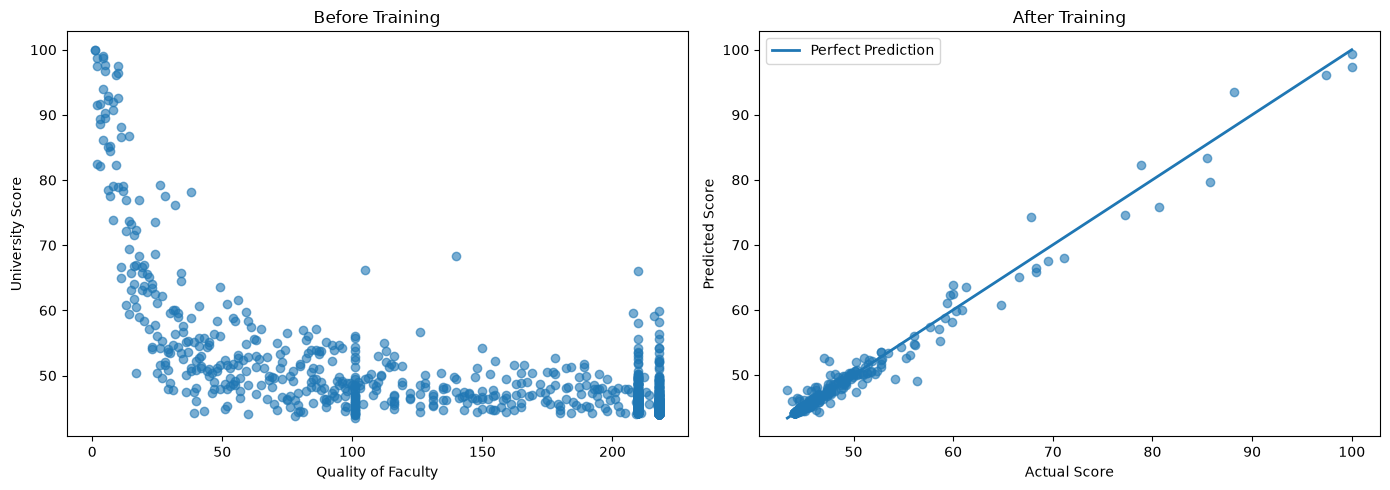

In [34]:
# Before training: relationship between one feature and the target

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)

plt.scatter(
    X_train["quality_of_faculty"],
    y_train,
    alpha=0.6
)

plt.title("Before Training")
plt.xlabel("Quality of Faculty")
plt.ylabel("University Score")

# After training

plt.subplot(1, 2, 2)

plt.scatter(
    y_test,
    y_pred_forest,
    alpha=0.6
)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linewidth=2,
    label="Perfect Prediction"
)

plt.title("After Training")
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.legend()

plt.tight_layout()
plt.show()

# Save the Best Model

The Random Forest Regressor achieved the best performance among all the trained models. Therefore, it is selected for deployment.

The trained model is saved using the **joblib** library so that it can later be loaded by the FastAPI application without retraining.

In [35]:
# Store all trained models
trained_models = {
    "Linear Regression": linear_model,
    "Gradient Descent (SGD)": gradient_model,
    "Decision Tree": decision_tree,
    "Random Forest": random_forest
}


# Select the model with the lowest loss
best_model = trained_models[best_model_name]


# Create model directory
os.makedirs("../../summative/models", exist_ok=True)


# Save best model
joblib.dump(
    best_model,
    "../../summative/models/best_model.pkl"
)


# Save scaler
joblib.dump(
    scaler,
    "../../summative/models/scaler.pkl"
)


# Save model name for API preprocessing decisions
joblib.dump(
    best_model_name,
    "../../summative/models/model_name.pkl"
)


print("Best model saved successfully")
print(f"Selected Model: {best_model_name}")

Best model saved successfully
Selected Model: Random Forest


# Prediction Script — Testing on a Single Row

To verify that the saved model performs correctly, a single sample from the test dataset is used to generate a prediction.

The predicted university score is then compared with the actual score. This step confirms that the model is ready to be integrated into the FastAPI application for deployment.

In [36]:
# Select one test sample
sample_index = 0

sample_row = X_test.iloc[[sample_index]]

actual_value = y_test.iloc[sample_index]


# Load saved artifacts
loaded_model = joblib.load("../../summative/models/best_model.pkl")
loaded_scaler = joblib.load("../../summative/models/scaler.pkl")
loaded_model_name = joblib.load("../../summative/models/model_name.pkl")


# Apply preprocessing depending on model type

if loaded_model_name in [
    "Linear Regression",
    "Gradient Descent (SGD)"
]:

    sample_input = loaded_scaler.transform(sample_row)

else:

    sample_input = sample_row


# Prediction

predicted_value = loaded_model.predict(sample_input)[0]


# Results

print("Model Used:")
print(loaded_model_name)


print("\nSample Input:")
display(sample_row)


print(f"\nActual Score: {actual_value:.2f}")

print(f"Predicted Score: {predicted_value:.2f}")

print(
    f"Prediction Error: {abs(actual_value - predicted_value):.2f}"
)

Model Used:
Random Forest

Sample Input:


,quality_of_education,alumni_employment,quality_of_faculty,publications,influence,citations,broad_impact,patents,year
1451,367,334,218,200,184,136,225.0,411,2015



Actual Score: 46.53
Predicted Score: 46.87
Prediction Error: 0.34
